# Lists


In [1]:
import sys
from pathlib import Path

# Find project root by looking for _config.yml
current = Path.cwd()
for parent in [current, *current.parents]:
    if (parent / '_config.yml').exists():
        project_root = parent
        break
else:
    project_root = Path.cwd().parent.parent

# Add project root to path
sys.path.insert(0, str(project_root))

# Import shared teaching helpers and cell magics
from shared import thinkpython, diagram, jupyturtle, structshape
from shared.download import download


```{contents}
:local:
:depth: 2
```

Programs often work with many related values at once: the scores in a class, the items in a shopping cart, the words in a sentence. Storing each value in its own variable (`score1`, `score2`, ...) does not scale. A **list** holds any number of values in a single variable, keeps them in order, and lets you add, remove, and change them as your program runs. Lists are the most widely used collection in Python, and most data work starts with one.

This section covers what lists are, how to create and access them, how to update and transform them, and how to combine these tools in practice. Section 6.2 covers what happens when two names refer to the same list, and how to copy lists safely.

## What Lists Are

### List Behavior

If you know another programming language, Python lists are similar to arrays in Java, C++, or JavaScript, but more flexible: a list can grow or shrink, and it can hold values of different types.

A Python **list** is a **sequence** type, like strings and tuples. All sequences are ordered collections that support indexing, slicing, `len()`, membership testing with `in`, and iteration.

Lists differ from strings in two ways:
- A string holds only characters; a list can hold values of **any type**. The values in a list are called its **elements**.
- Lists are **mutable**: you can change them after you create them.

The following figure shows the state diagram for `fruits`, `numbers` and `empty`. **Lists are objects** in Python's memory. When you create a list, Python creates a **list object** that holds your data in a specific order, and the variable holds a **reference** to that object.


In [2]:
numbers = [42, 123]
fruits = ['apple', 'banana', 'cherry']
empty = []

In [3]:
numbers = [42, 123]
fruits = ['apple', 'banana', 'cherry']
empty = []
from shared.diagram import make_list, Binding, Value

list1 = make_list(fruits, dy=-0.3, offsetx=0.17)
binding1 = Binding(Value('fruits'), list1)

list2 = make_list(numbers, dy=-0.3, offsetx=0.17)
binding2 = Binding(Value('numbers'), list2)

list3 = make_list(empty, dy=-0.3, offsetx=0.1)
binding3 = Binding(Value('empty'), list3)

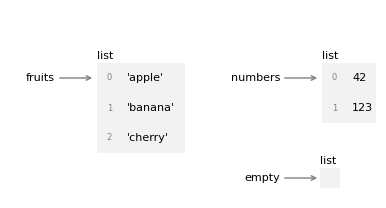

In [4]:
from shared.diagram import diagram, adjust, Bbox

width, height, x, y = [3.66, 1.88, 0.45, 1.2]
ax = diagram(width, height)
bbox1 = binding1.draw(ax, x, y)
bbox2 = binding2.draw(ax, x+2.25, y)
bbox3 = binding3.draw(ax, x+2.25, y-1.0)

bbox = Bbox.union([bbox1, bbox2, bbox3])
#adjust(x, y, bbox)

In [5]:
### EXERCISE: Describe a List *(basic)*
record = ['Alice', 21, 3.8, True]
# 1. Print the number of elements in record using len()
# 2. Check whether 21 is in record using the in operator
# 3. Loop over record and print each element followed by its type,
#    for example: Alice <class 'str'>
### Your code starts here:



### Your code ends here.

In [6]:
### Solution
record = ['Alice', 21, 3.8, True]

print(len(record))
print(21 in record)

for item in record:
    print(item, type(item))

4
True
Alice <class 'str'>
21 <class 'int'>
3.8 <class 'float'>
True <class 'bool'>


## Creating and Accessing Lists

There are several ways to create a new list:

- **Square brackets `[]`**: Enclose elements in square brackets to write a list literal
- **`list()` constructor**: Convert any iterable (strings, ranges, tuples, etc.) into a list
- **List comprehension**: Create lists using a concise expression-based syntax
- **`split()` method**: Convert a string into a list of words or parts
- **Nested lists**: Create lists containing other lists as elements

### Square Brackets

The most common way to create a list is by enclosing comma-separated values in square brackets `[]`.

**Syntax:**
```python
list_name = [element1, element2, element3, ...]
```

The elements can be of any type, and you can mix different types in the same list.

In [7]:
# Using square brackets - sequences of items

numbers = [1, 2, 3, 4, 5]               # a list of integers
fruits = ['apple', 'banana', 'cherry']  # a list of strings
empty = []                              # an empty list

print(fruits)
print(numbers)
print(empty)

['apple', 'banana', 'cherry']
[1, 2, 3, 4, 5]
[]


In [8]:
### EXERCISE: Create Different Types of Lists *(basic)*
# Create the following lists:
# 1. A list called 'colors' with three color names
# 2. An empty list called 'empty_list'
# 3. A list called 'mixed' with a string, an integer, and a float
### Your code starts here:



### Your code ends here.

In [9]:
### Solution
colors = ['red', 'blue', 'green']
empty_list = []
mixed = ['hello', 42, 3.14]

print(f"Colors: {colors}")
print(f"Empty list: {empty_list}")
print(f"Mixed list: {mixed}")

Colors: ['red', 'blue', 'green']
Empty list: []
Mixed list: ['hello', 42, 3.14]


### `list()` Constructor

The `list()` constructor converts any **iterable** (strings, ranges, tuples, etc.) into a list. This is useful when you need to convert data from one sequence type to another.

In [10]:
chars = list('spam')            # a list of characters
nums = list(range(5))           # a list of numbers from 0 to 4
tuple_data = (1, 2, 3)
list_data = list(tuple_data)    # a list created from a tuple

print(chars)
print(nums)
print(list_data)

['s', 'p', 'a', 'm']
[0, 1, 2, 3, 4]
[1, 2, 3]


In [11]:
### EXERCISE: Convert Using list() Constructor *(basic)*
# 1. Convert the string "Python" into a list of characters
# 2. Create a list of numbers from 10 to 14 using range() and list()
### Your code starts here:



### Your code ends here.

In [12]:
### Solution
chars = list('Python')
numbers = list(range(10, 15))

print(f"Characters: {chars}")
print(f"Numbers: {numbers}")

Characters: ['P', 'y', 't', 'h', 'o', 'n']
Numbers: [10, 11, 12, 13, 14]


### List Comprehensions

A **list comprehension** builds a new list from an existing sequence or range in a single expression. It is the Pythonic replacement for a `for` loop that appends items to a list.

**Basic Syntax:**
```python
[expression for item in iterable]
```

**With Condition:**
```python
[expression for item in iterable if condition]
```

In [13]:
# Traditional way
squares = []
for x in range(5):
    squares.append(x**2)
print("Traditional:", squares)

# List comprehension way
squares = [x**2 for x in range(5)]
print("Comprehension:", squares)

# With condition
even_squares = [x**2 for x in range(10) if x % 2 == 0]
print("Even squares:", even_squares)

Traditional: [0, 1, 4, 9, 16]
Comprehension: [0, 1, 4, 9, 16]
Even squares: [0, 4, 16, 36, 64]


In [14]:
# More complex list comprehensions
words = ['hello', 'world', 'python', 'programming']

# Get lengths of words
lengths = [len(word) for word in words]
print("Word lengths:", lengths)

# Get uppercase words longer than 5 characters
long_words = [word.upper() for word in words if len(word) > 5]
print("Long words:", long_words)

# Nested comprehension - flatten a 2D list
matrix = [[1, 2, 3], [4, 5, 6], [7, 8, 9]]
flattened = [item for row in matrix for item in row]
print("Flattened:", flattened)

Word lengths: [5, 5, 6, 11]
Long words: ['PYTHON', 'PROGRAMMING']
Flattened: [1, 2, 3, 4, 5, 6, 7, 8, 9]


In [15]:
### EXERCISE: Filter a List with a Comprehension *(basic)*
# Create a new list with only words longer than 5 characters 
# Hint: use len() function
### Your code starts here:
words = ['apple', 'banana', 'cherry', 'date', 'elderberry']



### Your code ends here.

In [16]:
### Solution
words = ['apple', 'banana', 'cherry', 'date', 'elderberry']
long_words = [word for word in words if len(word) > 5]
print(long_words)

['banana', 'cherry', 'elderberry']


In [17]:
### EXERCISE: List Comprehension Practice *(applied)*
# 1. Create a list of cubes (x^3) for numbers 1 through 5
# 2. Create a list of only odd numbers from 1 to 20
### Your code starts here:



### Your code ends here.

In [18]:
### Solution
cubes = [x**3 for x in range(1, 6)]
odds = [x for x in range(1, 21) if x % 2 != 0]

print(f"Cubes: {cubes}")
print(f"Odd numbers: {odds}")

Cubes: [1, 8, 27, 64, 125]
Odd numbers: [1, 3, 5, 7, 9, 11, 13, 15, 17, 19]


### Lists and Strings

Strings and lists often work together, and you will frequently convert one into the other.

A string is a sequence of characters and a list is a sequence of values, but a list of characters is not the same as a string. To convert a string to a list of individual characters, use the `list()` function (covered earlier). To break a string into words or parts, use the `split()` method shown below.

#### `split()` Method

The `split()` method breaks a string into a list of words or parts based on a delimiter. By default, it splits on whitespace.

In [19]:
# Split by whitespace (default)
words = 'hello world python'.split()
print(words)

# Split by custom delimiter
data = 'apple,banana,cherry'.split(',')
print(data)

['hello', 'world', 'python']
['apple', 'banana', 'cherry']


You can also use an optional **delimiter** argument to specify which characters to use as word boundaries:

In [20]:
s = 'ex-parrot'
t = s.split('-')
print(t)  # ['ex', 'parrot']

['ex', 'parrot']


#### `join()` Method

If you have a list of strings, you can concatenate them into a single string using `join()`. Note that `join()` is a string method, so you invoke it on the delimiter and pass the list as an argument.

In [21]:
delimiter = ' '
t = ['pining', 'for', 'the', 'fjords']
s = delimiter.join(t)
s

'pining for the fjords'

In this case the delimiter is a space character, so `join` puts a space
between words.
To join strings without spaces, you can use the empty string, `''`, as a delimiter.

In [22]:
### EXERCISE: Using split() and join() *(applied)*
# 1. Split the sentence "Python is an amazing language" into a list of words
# 2. Split the string "2026-02-16" by the delimiter "-"
# 3. Take the sentence "Python programming is fun",
#    split it into words, and
#    join the words back together with " - "
### Your code starts here:



### Your code ends here.

In [23]:
### Solution
# 1. Split sentence into words
sentence = "Python is an amazing language"
words = sentence.split()

# 2. Split date string by delimiter
date_string = "2026-02-16"
date_parts = date_string.split("-")

# 3. Split and join with a new delimiter
sentence2 = "Python programming is fun"
words2 = sentence2.split()
result = " - ".join(words2)

print(f"1. Words: {words}")
print(f"2. Date parts: {date_parts}")
print(f"3. Joined with ' - ': {result}")

1. Words: ['Python', 'is', 'an', 'amazing', 'language']
2. Date parts: ['2026', '02', '16']
3. Joined with ' - ': Python - programming - is - fun


### Nested Lists

A list can contain other lists. Each nested list counts as a single element of the outer list.

The list below contains a string, a float, an integer, and another list. It looks as if it has more than four items, but `len(mixed_list)` is 4, because the nested list counts as one element.

In [24]:
numbers = [1, 2, 3, 4, 5]
mixed_list = ['spam', 2.0, 5, numbers ]

print(mixed_list)
print(f"There are {len(mixed_list)} elements in the mixed list.")

['spam', 2.0, 5, [1, 2, 3, 4, 5]]
There are 4 elements in the mixed list.


In [25]:
nested_list = [ 
               [1, 2], 
               [3, 4], 
               [5, 6]
               ]
print(nested_list)
print(f"The nested list has {len(nested_list)} elements and they are lists themselves.")

[[1, 2], [3, 4], [5, 6]]
The nested list has 3 elements and they are lists themselves.


In [26]:
### EXERCISE: Working with Nested Lists *(applied)*
matrix = [[1, 2, 3], [4, 5, 6], [7, 8, 9]]
# 1. Access the second row (index 1)
# 2. Access the element in the first row, third column (value should be 3)
# 3. Calculate the total number of elements (not rows) using len()
### Your code starts here:



### Your code ends here.

In [27]:
### Solution
matrix = [[1, 2, 3], [4, 5, 6], [7, 8, 9]]
second_row = matrix[1]
element_1_3 = matrix[0][2]
total_elements = len(matrix) * len(matrix[0])  # rows * cols

print(f"Second row: {second_row}")
print(f"Element at [0][2]: {element_1_3}")
print(f"Total elements: {total_elements}")

Second row: [4, 5, 6]
Element at [0][2]: 3
Total elements: 9


### Accessing List Elements

Python gives you two ways to read data from a list: **indexing** gets a single element, and **slicing** gets a sublist.

List indices work the same way as string indices:
- Indexing is **zero-based**: the first element is at index `0`, the second at index `1`, and so on. Think of the index as the offset from the start of the list.
- Any integer expression can be used as an index.
- Reading or writing an index that does not exist raises an `IndexError`.
- A negative index counts backward from the end, starting with `-1` for the last element.

#### Indexing

Indexing reads or writes a single element with the **bracket operator**: `lst[index]`. For example, if `fruits = ['apple', 'banana', 'cherry']`, then `fruits[0]` returns `'apple'` and `fruits[-1]` returns `'cherry'`.

In [28]:
fruits = ['apple', 'banana', 'cherry', 'date', 'elderberry']
first = fruits[0]
last = fruits[-1]

print(f"First: {first}, Last: {last}")

First: apple, Last: elderberry


#### Slicing

Slicing selects a **subsequence** of a list with `lst[start:stop]` or `lst[start:stop:step]`:

- `start` is the index where the slice begins (inclusive).
- `stop` is the index where the slice ends (exclusive).
- `step` controls how many positions to advance (defaults to `1`). Use `2` to skip every other element, or `-1` to reverse.
- If you omit `start`, the slice begins at the start of the list.
- If you omit `stop`, the slice runs to the end of the list.
- Slicing does not modify the original list; it returns a **new list** containing the selected elements.

In [29]:
fruits = ['apple', 'banana', 'cherry', 'date', 'elderberry']

middle_three = fruits[1:4]      # elements at indices 1, 2, 3
from_start = fruits[:3]         # first three elements
to_end = fruits[2:]             # from index 2 to end
every_other = fruits[::2]       # step=2: every second element
reversed_fruits = fruits[::-1]  # step=-1: reverses the list

print(f"Middle three: {middle_three}")
print(f"From start: {from_start}")
print(f"To end: {to_end}")
print(f"Every other: {every_other}")
print(f"Reversed: {reversed_fruits}")

Middle three: ['banana', 'cherry', 'date']
From start: ['apple', 'banana', 'cherry']
To end: ['cherry', 'date', 'elderberry']
Every other: ['apple', 'cherry', 'elderberry']
Reversed: ['elderberry', 'date', 'cherry', 'banana', 'apple']


The `step` value lets you skip elements, reverse a list, or take items at regular intervals:

In [30]:
numbers = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

print(f"Every other: {numbers[::2]}")
print(f"Every third: {numbers[::3]}")
print(f"Reversed: {numbers[::-1]}")
print(f"Every other, reversed: {numbers[::-2]}")
print(f"Slice from 1 to 8, step 2: {numbers[1:8:2]}")
print(f"Backwards from 7 to 2: {numbers[7:2:-1]}")     # reversing

Every other: [0, 2, 4, 6, 8]
Every third: [0, 3, 6, 9]
Reversed: [9, 8, 7, 6, 5, 4, 3, 2, 1, 0]
Every other, reversed: [9, 7, 5, 3, 1]
Slice from 1 to 8, step 2: [1, 3, 5, 7]
Backwards from 7 to 2: [7, 6, 5, 4, 3]


In [31]:
### EXERCISE: Indexing and Slicing Practice *(basic)*
fruits = ['apple', 'banana', 'cherry', 'date', 'elderberry', 'fig']
# 1. Get the third element (index 2)
# 2. Get the last element using negative indexing
# 3. Get a slice of elements from index 1 to 4 (not including 4)
# 4. Get every other element
### Your code starts here:



### Your code ends here.

In [32]:
### Solution
fruits = ['apple', 'banana', 'cherry', 'date', 'elderberry', 'fig']
third = fruits[2]
last = fruits[-1]
slice_1_to_4 = fruits[1:4]
every_other = fruits[::2]

print(f"Third element: {third}")
print(f"Last element: {last}")
print(f"Slice [1:4]: {slice_1_to_4}")
print(f"Every other: {every_other}")

Third element: cherry
Last element: fig
Slice [1:4]: ['banana', 'cherry', 'date']
Every other: ['apple', 'cherry', 'elderberry']


#### Query Methods

`count()` returns how many times a value appears in a list, and `index()` returns the position of its first occurrence. Neither method changes the list.

In [33]:
# count() - Returns number of times element appears
numbers = [1, 2, 3, 2, 4, 2, 5]
count = numbers.count(2)
print(f"The number 2 appears {count} times")

# index() - Returns index of first occurrence
letters = ['a', 'b', 'c', 'b', 'd']
position = letters.index('b')
print(f"First 'b' is at index: {position}")

The number 2 appears 3 times
First 'b' is at index: 1


In [34]:
### EXERCISE: Query a List *(basic)*
votes = ['yes', 'no', 'yes', 'yes', 'abstain', 'no']
# 1. Count how many 'yes' votes there are
# 2. Find the index of the first 'no' vote
# 3. Find the index of the 'abstain' vote
### Your code starts here:



### Your code ends here.

In [35]:
### Solution
votes = ['yes', 'no', 'yes', 'yes', 'abstain', 'no']

print(f"Yes votes: {votes.count('yes')}")
print(f"First 'no' at index: {votes.index('no')}")
print(f"'abstain' at index: {votes.index('abstain')}")

Yes votes: 3
First 'no' at index: 1
'abstain' at index: 4


## Updating and Transforming Lists

Python gives you three kinds of tools for working with lists: operators, built-in functions, and methods.

In [36]:
fruits = ['apple', 'banana', 'cherry']


### List Operators

Python supports several operators that work directly with lists:

| Operator | Name | Description | Example | Result |
|----------|------|-------------|---------|--------|
| `+` | Concatenation | Combines two lists | `[1, 2] + [3, 4]` | `[1, 2, 3, 4]` |
| `*` | Repetition | Repeats a list | `[1, 2] * 3` | `[1, 2, 1, 2, 1, 2]` |
| **`in`** | **Membership** | Checks if item exists in list | `3 in [1, 2, 3]` | `True` |
| `not in` | Non-membership | Checks if item doesn't exist | `5 not in [1, 2, 3]` | `True` |
| `[]` | Indexing | Accesses element by position | `[10, 20, 30][0]` | `10` |
| **`[:]`** | **Slicing** | Extracts portion of list | `[0, 1, 2, 3][1:3]` | `[1, 2]` |
| **`==`** | **Equality** | Checks if lists are equal | `[1, 2] == [1, 2]` | `True` |
| `!=` | Inequality | Checks if lists are not equal | `[1, 2] != [1, 3]` | `True` |
| `<` | Less than | Lexicographic comparison | `[1, 2] < [1, 3]` | `True` |
| `>` | Greater than | Lexicographic comparison | `[1, 3] > [1, 2]` | `True` |
| `<=` | Less than or equal | Lexicographic comparison | `[1, 2] <= [1, 2]` | `True` |
| `>=` | Greater than or equal | Lexicographic comparison | `[1, 3] >= [1, 2]` | `True` |

The `+` operator concatenates lists.

In [37]:
num1 = [1, 2, 3]
num2 = [4, 5, 6]

num1 + num2

[1, 2, 3, 4, 5, 6]

The `*` operator repeats a list a given number of times.

In [38]:
['spam'] * 4

['spam', 'spam', 'spam', 'spam']

In [39]:
### EXERCISE: List Concatenation and Repetition *(basic)*
# 1. Create two lists: list1 = [1, 2, 3] and list2 = [4, 5, 6]
# 2. Concatenate them to create list3
# 3. Create list4 by repeating [0] three times
### Your code starts here:



### Your code ends here.

In [40]:
### Solution
list1 = [1, 2, 3]
list2 = [4, 5, 6]
list3 = list1 + list2
list4 = [0] * 3

print(f"List1 + List2: {list3}")
print(f"[0] * 3: {list4}")

List1 + List2: [1, 2, 3, 4, 5, 6]
[0] * 3: [0, 0, 0]


#### Membership Testing

The `in` operator checks whether a given element appears anywhere in the list.

In [41]:
'apple' in fruits

True

In [42]:
print('tomato' in fruits)
print('tomato' not in fruits)

False
True


When you check membership with `in`, only top-level elements count. For example, `'spam'` is an element of `mixed_list`, but `9` is not, because `9` is inside the nested list:

In [43]:
numbers = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
mixed_list = ['spam', 2.0, 5, numbers ]

print('spam' in mixed_list)     # True
print(9 in mixed_list)          # False: 9 is inside the nested list

True
False


Membership tests produce Boolean values, and Python treats `True` as `1` and `False` as `0` in arithmetic. That means `sum()` can count how many items in a list of Booleans are `True`. Combined with a list comprehension, this is a common way to count how many items meet a condition.

In [44]:
print(sum([True, False, True]))    # True counts as 1, False as 0

scores = [72, 88, 55, 95, 61]
passed = sum([score >= 60 for score in scores])
print(f"{passed} of {len(scores)} students passed")

2
4 of 5 students passed


In [45]:
### EXERCISE: Membership Testing *(applied)*
inventory = ['apple', 'banana', 'orange', 'grape', 'mango']
# 1. Check if 'orange' is in the inventory
# 2. Check if 'strawberry' is NOT in the inventory
# 3. Create a list of items to check: ['apple', 'kiwi', 'grape']
#    and count how many of them are in inventory using a 
#    LIST COMPREHENSION and sum()
### Your code starts here:



### Your code ends here.

In [46]:
### Solution
inventory = ['apple', 'banana', 'orange', 'grape', 'mango']
has_orange = 'orange' in inventory
no_strawberry = 'strawberry' not in inventory

check_items = ['apple', 'kiwi', 'grape']
count_found = sum( [item in inventory for item in check_items] ) 
# .count(True) is not needed because True is treated as 1 and False as 0 in sum()

print(f"Has orange: {has_orange}")
print(f"No strawberry: {no_strawberry}")
print(f"Items found in inventory: {count_found}")

Has orange: True
No strawberry: True
Items found in inventory: 2


### List Functions and Methods

Python gives you two kinds of tools for working with lists. **Built-in functions** take the list as an argument, as in `len(lst)`. **Methods** belong to the list and are called with a dot, as in `lst.append(x)`.

**Built-in functions**

These functions never change the list you pass in.

| Function | Description | Example | Result |
|---|---|---|---|
| `len()` | Number of items | `len([1, 2, 3])` | `3` |
| `max()` | Largest item | `max([1, 2, 3])` | `3` |
| `min()` | Smallest item | `min([1, 2, 3])` | `1` |
| `sum()` | Sum of numeric items | `sum([1, 2, 3])` | `6` |
| `sorted()` | New sorted list | `sorted([3, 1, 2])` | `[1, 2, 3]` |
| `reversed()` | Reverse iterator | `list(reversed([1, 2, 3]))` | `[3, 2, 1]` |
| `list()` | New list from an iterable | `list('abc')` | `['a', 'b', 'c']` |

**List methods**

Each example starts from a fresh `lst`.

| Purpose | Method | Example | Returns | `lst` afterward |
|---|---|---|---|---|
| Adding | `append()` | `lst = [1, 2]; lst.append(3)` | `None` | `[1, 2, 3]` |
| | `insert()` | `lst = [1, 3]; lst.insert(1, 2)` | `None` | `[1, 2, 3]` |
| | `extend()` | `lst = [1, 2]; lst.extend([3, 4])` | `None` | `[1, 2, 3, 4]` |
| Removing | `remove()` | `lst = [1, 2, 3]; lst.remove(2)` | `None` | `[1, 3]` |
| | `pop()` | `lst = [1, 2, 3]; lst.pop()` | `3` | `[1, 2]` |
| | `pop(index)` | `lst = [1, 2, 3]; lst.pop(0)` | `1` | `[2, 3]` |
| | `clear()` | `lst = [1, 2, 3]; lst.clear()` | `None` | `[]` |
| Reordering | `sort()` | `lst = [3, 1, 2]; lst.sort()` | `None` | `[1, 2, 3]` |
| | `reverse()` | `lst = [1, 2, 3]; lst.reverse()` | `None` | `[3, 2, 1]` |
| Querying | `index()` | `lst = [1, 2, 3]; lst.index(2)` | `1` | unchanged |
| | `count()` | `lst = [1, 2, 2, 3]; lst.count(2)` | `2` | unchanged |
| Copying | `copy()` | `lst = [1, 2, 3]; lst.copy()` | `[1, 2, 3]` (new list) | unchanged |

Methods that modify a list in place return `None`. A common mistake is writing `lst = lst.append(3)`, which sets `lst` to `None`. Call the method on its own line instead: `lst.append(3)`.

Compare `sorted(lst)` with `lst.sort()`. The function returns a new sorted list and leaves `lst` alone. The method sorts `lst` itself and returns `None`.

The examples below show these tools in action.

#### List Functions

The built-in functions from the table work on any list.

The `len` function returns the **length** of a list: the number of elements it holds.

In [47]:
numbers = [1, 2, 3, 4, 5]
fruits = ['apple', 'banana', 'cherry', 'date', 'elderberry']
print(f"There are {len(numbers)} numbers in {numbers}.")
print(f"There are {len(fruits)} fruits in {fruits}.")

There are 5 numbers in [1, 2, 3, 4, 5].
There are 5 fruits in ['apple', 'banana', 'cherry', 'date', 'elderberry'].


The length of an empty list is `0`.

In [48]:
empty = []
len(empty)

0

Other arithmetic operators, such as `-` and `/`, do not work with lists. To add up the elements, use `sum`; to find the smallest and largest, use `min` and `max`.

In [49]:
num1 = [1, 2, 3]
num2 = [4, 5, 6]

print(sum(num1))
print(min(num1))
print(max(num2))

6
1
6


In [50]:
### EXERCISE: Summarize with Built-in Functions *(basic)*
temps = [68, 74, 71, 80, 77]
# 1. Print the number of readings, the highest reading, and the lowest reading
# 2. Compute the average reading with sum() and len()
# 3. Print a sorted version of temps with sorted(),
#    then print temps to show that it is unchanged
### Your code starts here:



### Your code ends here.

In [51]:
### Solution
temps = [68, 74, 71, 80, 77]

print(f"Readings: {len(temps)}, highest: {max(temps)}, lowest: {min(temps)}")
print(f"Average: {sum(temps) / len(temps)}")
print(f"Sorted: {sorted(temps)}")
print(f"Original: {temps}")

Readings: 5, highest: 80, lowest: 68
Average: 74.0
Sorted: [68, 71, 74, 77, 80]
Original: [68, 74, 71, 80, 77]


#### List Modifying Methods

Lists have built-in methods that allow you to modify them in place, such as adding, removing, or reordering elements.

In [52]:
letters = ['a', 'b', 'c', 'd']
print(f"Original list:\t\t {letters}")

# append() - Adds element to the end
letters.append('e')
print(f"After append 'e':\t {letters}")

# extend() - Appends all elements from another list
letters.extend(['f', 'g'])
print(f"After extend ['f', 'g']: {letters}")

# insert() - Inserts element at specific position
letters.insert(0, 'z')
print(f"After insert at 0:\t {letters}")

# remove() - Removes first occurrence of element
letters.remove('z')
print(f"After remove 'z':\t {letters}")

# pop() - Removes and returns element at index (or last if no index)
last_item = letters.pop()
print(f"Popped: {last_item}, Remaining:\t {letters}")

# clear() - Removes all elements
temp = [1, 2, 3]
temp.clear()
print(f"After clear:\t\t {temp}")

Original list:		 ['a', 'b', 'c', 'd']
After append 'e':	 ['a', 'b', 'c', 'd', 'e']
After extend ['f', 'g']: ['a', 'b', 'c', 'd', 'e', 'f', 'g']
After insert at 0:	 ['z', 'a', 'b', 'c', 'd', 'e', 'f', 'g']
After remove 'z':	 ['a', 'b', 'c', 'd', 'e', 'f', 'g']
Popped: g, Remaining:	 ['a', 'b', 'c', 'd', 'e', 'f']
After clear:		 []


**Note:** If you try to `remove()` an element that doesn't exist, Python raises a `ValueError`. If you try to `pop()` from an empty list, Python raises an `IndexError`.

In [53]:
### EXERCISE: Using List Methods *(basic)*
numbers = [3, 1, 4, 1, 5, 9, 2, 6]
# 1. Count how many times 1 appears in the list 
# 2. Append the number 7 to the end
# 3. Remove the first occurrence of 1
# 4. Find the index of the number 5
### Your code starts here:



### Your code ends here.

In [54]:
### Solution
numbers = [3, 1, 4, 1, 5, 9, 2, 6]
count_ones = numbers.count(1)
print(f"Count of 1s: {count_ones}")
numbers.append(7)
print(f"List after appending 7: {numbers}")
numbers.remove(1)
print(f"List after removing first occurrence of 1: {numbers}")
index_of_five = numbers.index(5)
print(f"Index of 5: {index_of_five}")


Count of 1s: 2
List after appending 7: [3, 1, 4, 1, 5, 9, 2, 6, 7]
List after removing first occurrence of 1: [3, 4, 1, 5, 9, 2, 6, 7]
Index of 5: 3


### Iteration Helpers: `enumerate` and `zip`

**Using `enumerate()`**

When looping through a list, you sometimes need to know both the **element** and its **index**. The `enumerate()` function returns pairs of `(index, element)` for each item in the list.

In [55]:
fruits = ['apple', 'banana', 'cherry']

for index, fruit in enumerate(fruits):
    print(f"{index}: {fruit}")

0: apple
1: banana
2: cherry


**Using `zip()`**

The `zip()` function is useful when you need to loop through two or more lists in parallel. It pairs up elements from each list and returns tuples.

In [56]:
names = ['Alice', 'Bob', 'Charlie']
ages = [25, 30, 35]
cities = ['New York', 'London', 'Tokyo']

for name, age, city in zip(names, ages, cities):
    print(f"{name} is {age} years old and lives in {city}")

Alice is 25 years old and lives in New York
Bob is 30 years old and lives in London
Charlie is 35 years old and lives in Tokyo


In [57]:
test = zip(names, ages, cities)
print(test)         # This will print a zip object, not the contents
print(list(test))   # Convert zip object to list to see contents

[('Alice', 25, 'New York'), ('Bob', 30, 'London'), ('Charlie', 35, 'Tokyo')]


In [58]:
### EXERCISE: Using enumerate() and zip() *(basic)*
# with the following lists:
fruits = ['apple', 'banana', 'cherry']
prices = [10, 20, 30]
# 1. Use enumerate() to print the index and fruit name 
#    as "0: apple", "1: banana", etc.
# 2. Use zip() to print each fruit with its corresponding price 
#    as "apple costs 10", "banana costs 20", etc.
### Your code starts here:



### Your code ends here.

In [59]:
### Solution

fruits = ['apple', 'banana', 'cherry']
prices = [10, 20, 30]

for index, fruit in enumerate(fruits):
    print(f"{index}: {fruit}")      

for fruit, price in zip(fruits, prices):
    print(f"{fruit} costs {price}")

0: apple
1: banana
2: cherry
apple costs 10
banana costs 20
cherry costs 30


### List Unpacking

**Unpacking** is a Python feature that allows you to assign **multiple values** from a list (or any iterable) to **multiple variables** in a single statement. Instead of accessing elements one by one with indexing, you can extract them all at once.

This makes your code more readable and **Pythonic**, especially when working with structured data.

#### Basic Unpacking

In [60]:
# Without unpacking (verbose)
point = [10, 20, 30]
x = point[0]
y = point[1]
z = point[2]

In [61]:
# With unpacking (concise)
point = [10, 20, 30]
x, y, z = point         # assigns 10 to x, 20 to y, 30 to z

In [62]:
# Unpacking actually works with any iterable

first, second = "hi"
print(f"first={first}, second={second}")

first=h, second=i


#### With Star Operator

- Using `*` (the **unpacking operator**) allows you to capture multiple elements.
- You can only have one `*variable` per unpacking statement.

In [63]:
# Capture the first element and the rest
numbers = [1, 2, 3, 4, 5]
first, *rest = numbers

print(f"First: {first}")
print(f"Rest: {rest}")

First: 1
Rest: [2, 3, 4, 5]


In [64]:
# Capture first, last, and middle
first, *middle, last = numbers
print(f"First: {first}, Middle: {middle}, Last: {last}")

First: 1, Middle: [2, 3, 4], Last: 5


In [65]:
# Capture last element
*most, last = numbers
print(f"Most: {most}, Last: {last}")

Most: [1, 2, 3, 4], Last: 5


In [66]:
# Unpacking works with all iterables, including 
# a string into individual characters

word = "Python"
first, *middle, last = word

print(f"First: {first}")
print(f"Middle: {middle}")
print(f"Last: {last}")

First: P
Middle: ['y', 't', 'h', 'o']
Last: n


#### Unpacking in Function Calls

The `*` operator can also unpack a list into function **arguments**:

In [67]:
# Unpack a list as function arguments
def display_info(name, age, city):
    print(f"{name} is {age} years old and lives in {city}")

person = ['Alice', 30, 'New York']
display_info(*person)  # unpacks to display_info('Alice', 30, 'New York')

Alice is 30 years old and lives in New York


In [68]:
# Useful with functions like print
values = [1, 2, 3, 4, 5]
print(*values)              # Prints: 1 2 3 4 5 (separated by spaces)
print(*values, sep='-')     # Prints: 1-2-3-4-5

1 2 3 4 5
1-2-3-4-5


**Common use cases:**
- Swapping values: `a, b = b, a`
- Parsing CSV data: `name, age, email = row.split(',')`
- Function returns: `min_val, max_val = find_min_max(numbers)`
- Ignoring values: `first, *_, last = data` (use `_` for values you don't need)

Here `_` is a conventional **throwaway variable name**: it signals that you don't need those values.

In [69]:
### EXERCISE: Unpack a Record *(applied)*
student = ['Alice', 'Chen', 92, 88, 95]
# 1. Unpack student into first, last, and a list called scores,
#    using a starred variable for the scores
# 2. Print the result as: Alice Chen: [92, 88, 95]
# 3. Unpack scores into first_quiz and ignore the rest with *_
#    then print first_quiz
### Your code starts here:



### Your code ends here.

In [70]:
### Solution
student = ['Alice', 'Chen', 92, 88, 95]

first, last, *scores = student
print(f"{first} {last}: {scores}")

first_quiz, *_ = scores
print(first_quiz)

Alice Chen: [92, 88, 95]
92


## Lists in Practice

This section applies list tools to common data tasks: checking a condition across a whole list with `any()` and `all()`, and a worked example that combines splitting, converting, filtering, sorting, and summarizing.

### `any()` and `all()`

`any(iterable)` returns `True` if at least one element is truthy.
`all(iterable)` returns `True` if every element is truthy (also `True` for an empty iterable).

Passing a **list comprehension** is the clearest way to express these checks when working with lists.

In [71]:
scores = [72, 88, 95, 61, 79]

# all(): True only if every element satisfies the condition
print(all([score >= 60 for score in scores]))   # True: everyone passed
print(all([score >= 90 for score in scores]))   # False: not everyone got an A

True
False


In [72]:
words = ['hello', 'world', 'programming', 'python']

# any(): True if at least one element satisfies the condition
print(any([len(word) > 10 for word in words]))          # True: 'programming'
print(any([word.startswith('z') for word in words]))    # False

True
False


Common patterns in data work:

- `all([score >= 60 for score in scores])`: check whether every student passed.
- `any([value is None for value in row])`: check for any missing value in a row.
- `all([column in columns for column in required])`: check that every required column is present.

In Chapter 11 (Iterators & Generators), you will see that the list brackets can be dropped, as in `any(x > 0 for x in values)`. That version avoids building the intermediate list and lets the function stop as soon as the result is known.

In [73]:
### EXERCISE: any() and all() *(basic)*
numbers = [2, 4, 6, 8, 9]
words = ['python', 'java', 'javascript', 'go']

# 1. Use all() with a list comprehension to check if all numbers are even.
# 2. Use any() with a list comprehension to check if any word starts with 'j'.
# 3. Use any() with a list comprehension to check if any number is greater than 10.
### Your code starts here:



### Your code ends here.

In [74]:
### Solution
numbers = [2, 4, 6, 8, 9]
words = ['python', 'java', 'javascript', 'go']

print(all([num % 2 == 0 for num in numbers]))        # False: 9 is odd
print(any([word.startswith('j') for word in words])) # True
print(any([num > 10 for num in numbers]))             # False

False
True
False


### Worked Example: Summarizing Quiz Scores

Data often arrives as text. Suppose one line of a file holds a student's quiz scores, separated by commas. The goal is to report how many quizzes the student took, the average score, the three best scores, and whether every score is passing (60 or above).

In [75]:
line = '72,88,55,95,61,79,90'

# 1. Split the text into a list of strings
parts = line.split(',')

# 2. Convert each string to an integer
scores = [int(part) for part in parts]

# 3. Filter: keep only the passing scores
passing = [score for score in scores if score >= 60]

# 4. Rank: sort a new list, reverse it, and take the first three
top_three = sorted(scores)[::-1][:3]

# 5. Summarize
print(f"Quizzes taken:  {len(scores)}")
print(f"Average score:  {round(sum(scores) / len(scores), 1)}")
print(f"Top three:      {top_three}")
print(f"Passing scores: {len(passing)} of {len(scores)}")
print(f"All passing?    {all([score >= 60 for score in scores])}")
print(f"Original order: {scores}")

Quizzes taken:  7
Average score:  77.1
Top three:      [95, 90, 88]
Passing scores: 6 of 7
All passing?    False
Original order: [72, 88, 55, 95, 61, 79, 90]


Each step uses a tool from earlier in this section:

- `split()` turns the text into a list of strings.
- A list comprehension converts each string with `int()`, and a comprehension with a condition filters the passing scores.
- `sorted()` returns a new sorted list, and slicing reverses it and keeps the first three.
- `len()`, `sum()`, and `all()` summarize the results.

Because `sorted()` returns a new list instead of sorting in place, `scores` keeps its original order for the last line.

In [76]:
### EXERCISE: Summarize Daily Temperatures *(applied)*
line = '68,74,59,80,77,63,71'
# 1. Split line and convert it to a list of integers called temps
# 2. Make a list of the readings that are 70 or above
# 3. Find the two lowest readings using sorted() and slicing
# 4. Print the average reading rounded to 1 decimal place,
#    and whether any reading is above 78
### Your code starts here:



### Your code ends here.

In [77]:
### Solution
line = '68,74,59,80,77,63,71'

temps = [int(part) for part in line.split(',')]
warm = [temp for temp in temps if temp >= 70]
lowest_two = sorted(temps)[:2]

print(f"Readings: {temps}")
print(f"70 or above: {warm}")
print(f"Two lowest: {lowest_two}")
print(f"Average: {round(sum(temps) / len(temps), 1)}")
print(f"Any above 78? {any([temp > 78 for temp in temps])}")

Readings: [68, 74, 59, 80, 77, 63, 71]
70 or above: [74, 80, 77, 71]
Two lowest: [59, 63]
Average: 70.3
Any above 78? True


## Summary

- A list is an ordered, mutable sequence that can hold values of any type, including other lists.
- Create lists with square brackets, `list()`, list comprehensions, or `split()`; read them with indexing and slicing.
- Operators, built-in functions, and methods update and transform lists. Methods that modify a list in place return `None`.
- `enumerate()`, `zip()`, and unpacking make loops and assignments over lists clearer.
- `any()` and `all()` check a condition across a whole list.

## Further Reading

- [More on Lists](https://docs.python.org/3/tutorial/datastructures.html#more-on-lists) and [List Comprehensions](https://docs.python.org/3/tutorial/datastructures.html#list-comprehensions), Python Tutorial
- [Sequence Types: list, tuple, range](https://docs.python.org/3/builtins/stdtypes.html#sequence-types-list-tuple-range), Python Standard Library documentation